## Reproduce plots

In [1]:
import sys;
if ".." not in sys.path: sys.path.append("..") # allows us to have visibility on our package without installing it in editing mode
import matplotlib.pyplot as plt
from monaqa2.data.hyperparams import load_best_qemc_gamma_t, export_best_gamma_t_h5
from monaqa2.data.instances import load_instances
from monaqa2.data.runtime import tight_schedule_annealing, make_prefix_stable_schedule_generator
from monaqa2.data.spectral_gap import run_experiment_to_generate_spectral_gaps, load_spectral_gap
from monaqa2.data.classical_query import run_experiment_to_generate_classical_queries
from monaqa2.mcmc.model import IsingModel, RandomIsingModel
import numpy as np

## Spectral gap plots

In [2]:
from monaqa2.data.plot_table18 import plot_spectral_gap_vs_beta_table
from monaqa2.data.plot_table18 import plot_spectral_gap_vs_n_table
from monaqa2.data.plot_table18 import plot_last_step_classical_queries_and_spectral_gap_vs_n_table
from monaqa2.data.plot_table18 import plot_annealing_classical_and_quantum_queries_vs_n_table, 

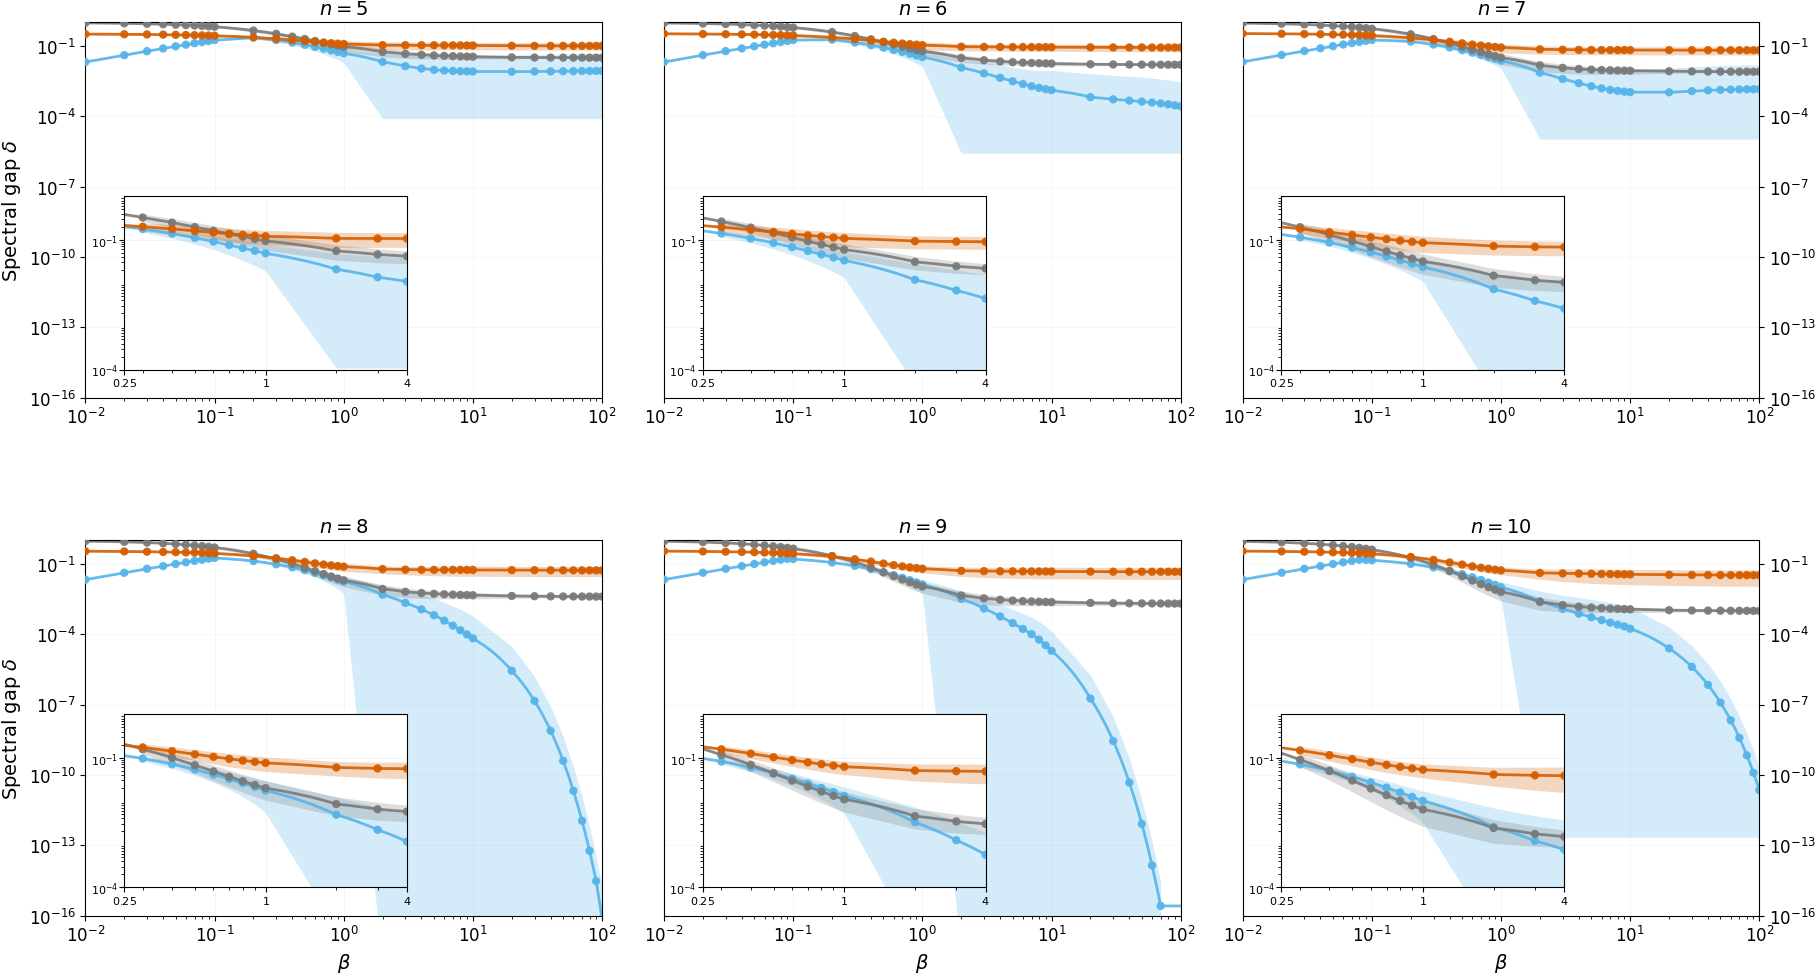

In [115]:
plt.close()
fig, ax = plot_spectral_gap_vs_beta_table(
    fixed_ns=[5, 6, 7, 8, 9, 10], 
    miniature_scale=1.25, 
    ncols=3, 
    statistic="mean+std",
    wspace=0.12,)
plt.savefig("plots/6_spectral_gap_vs_beta_stat_mean_std", dpi=300)

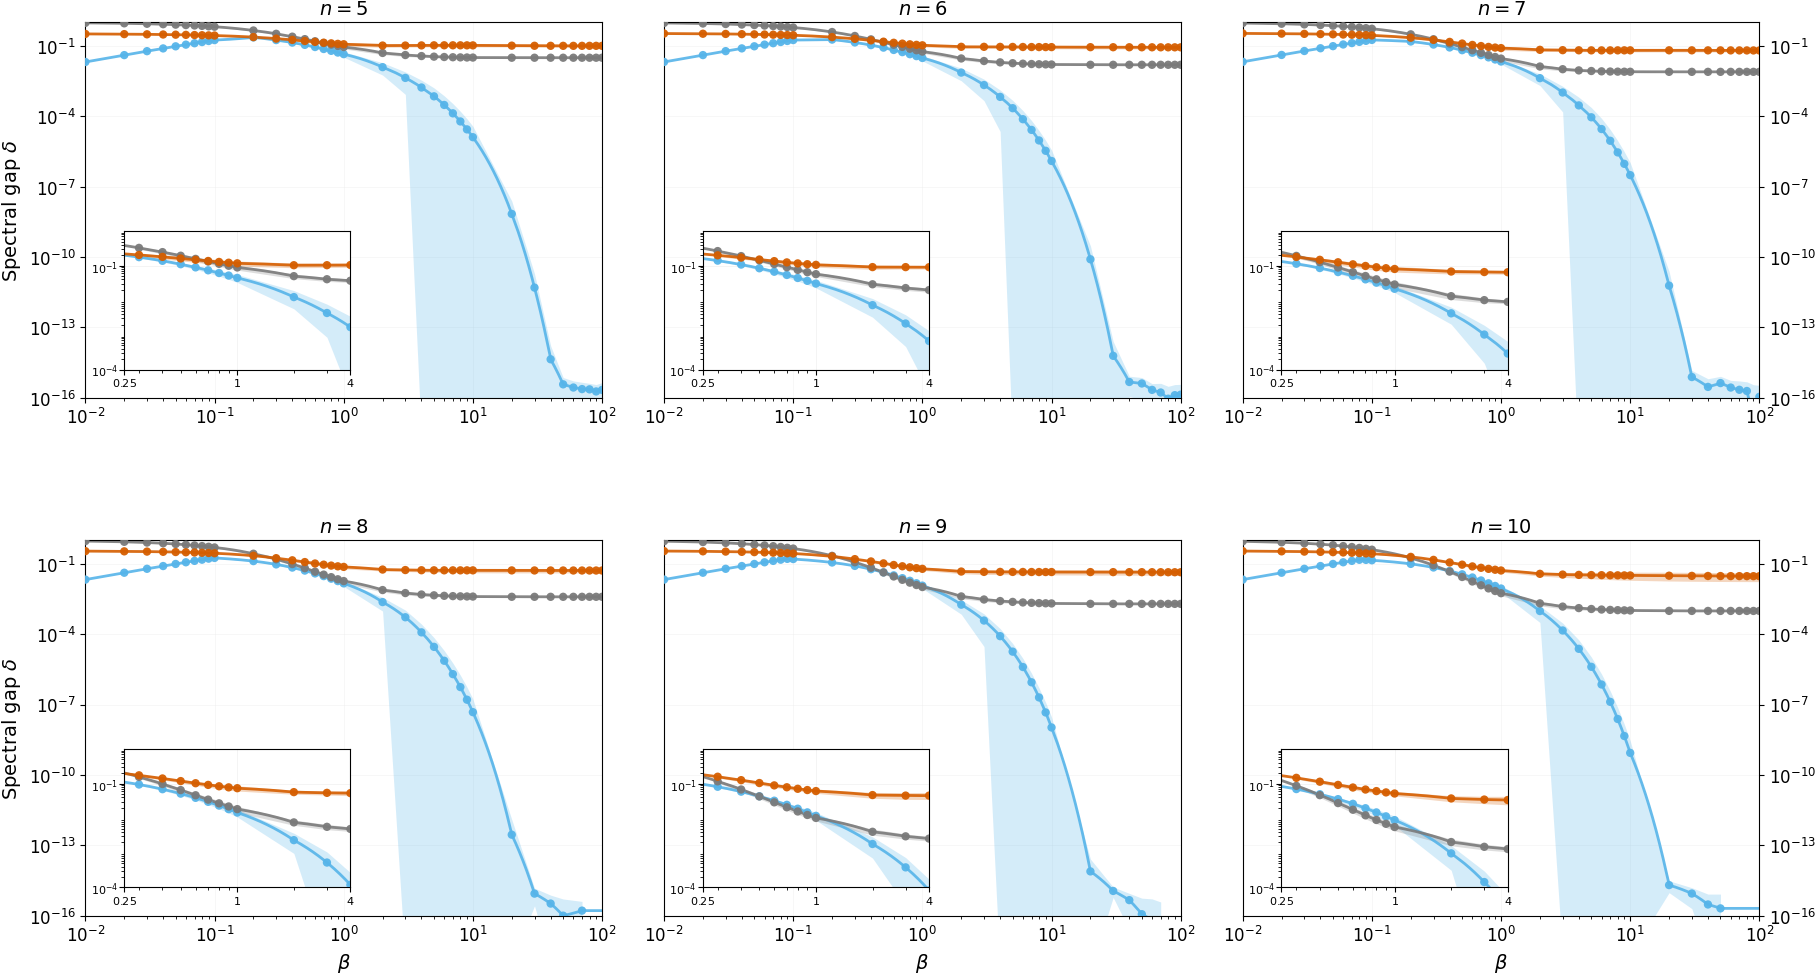

In [116]:
plt.close()
fig, ax = plot_spectral_gap_vs_beta_table(
    fixed_ns=[5, 6, 7, 8, 9, 10], 
    ncols=3, 
    statistic="mean+std-tail",
    wspace=0.12,)
plt.savefig("plots/6_spectral_gap_vs_beta_stat_mean_std_notail", dpi=300)

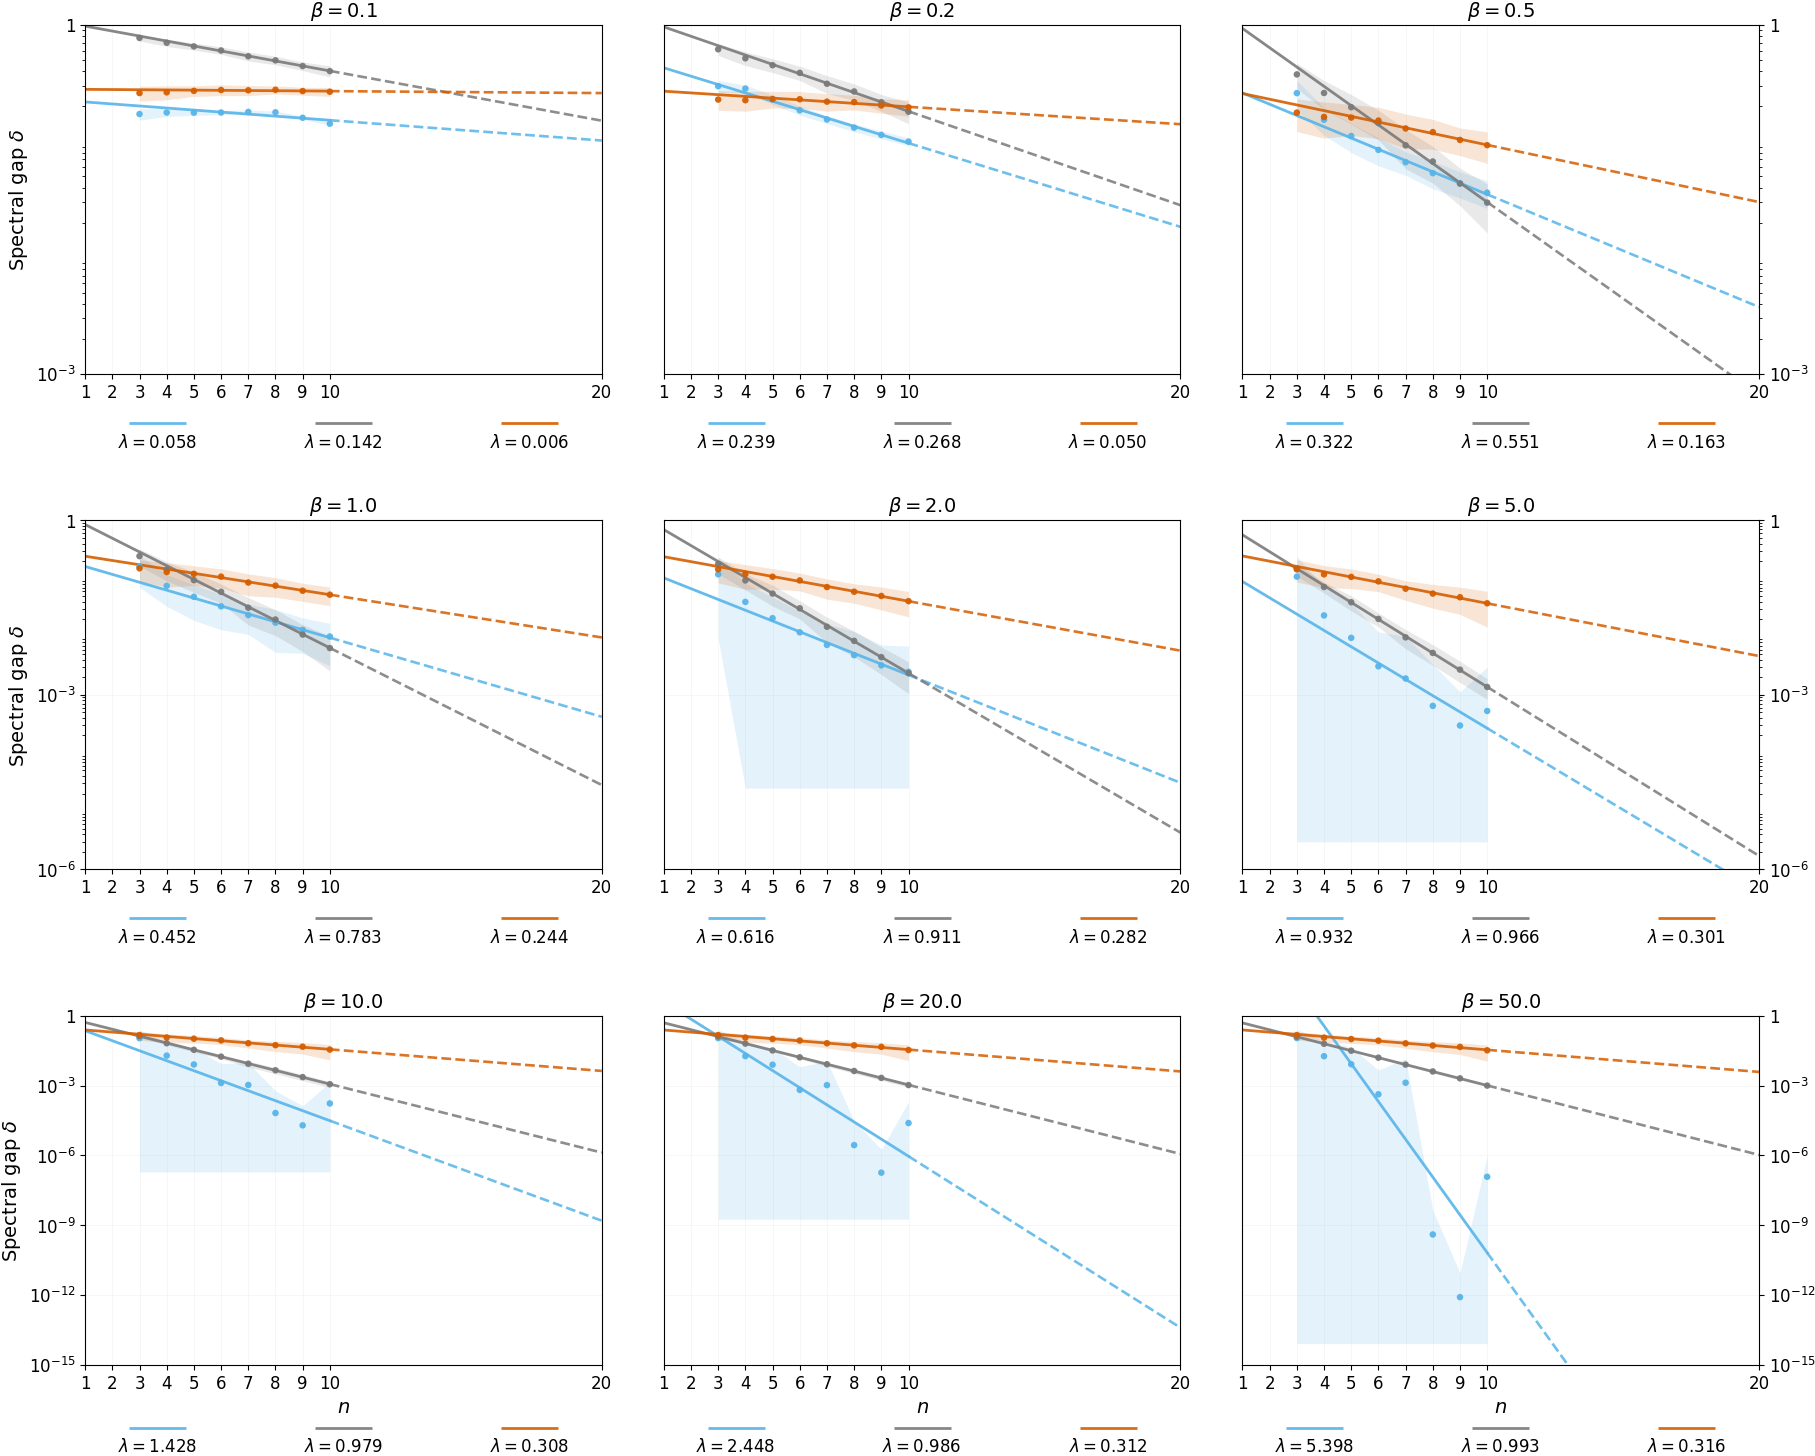

In [117]:
plt.close()
fig, ax = plot_spectral_gap_vs_n_table(fixed_betas=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], ncols=3, n_plot_min=1, n_plot_max=20, statistic="mean+std", show_legend=True,
    y_limit_measurement_scale=1.0,
    y_limit_max_extra_orders=5.0,
    y_tick_order_step=3,
    wspace=0.12,
    extrapolation_alpha_factor=0.95,)
plt.savefig("plots/6_spectral_gap_vs_n_stat_mean_std", dpi=300)

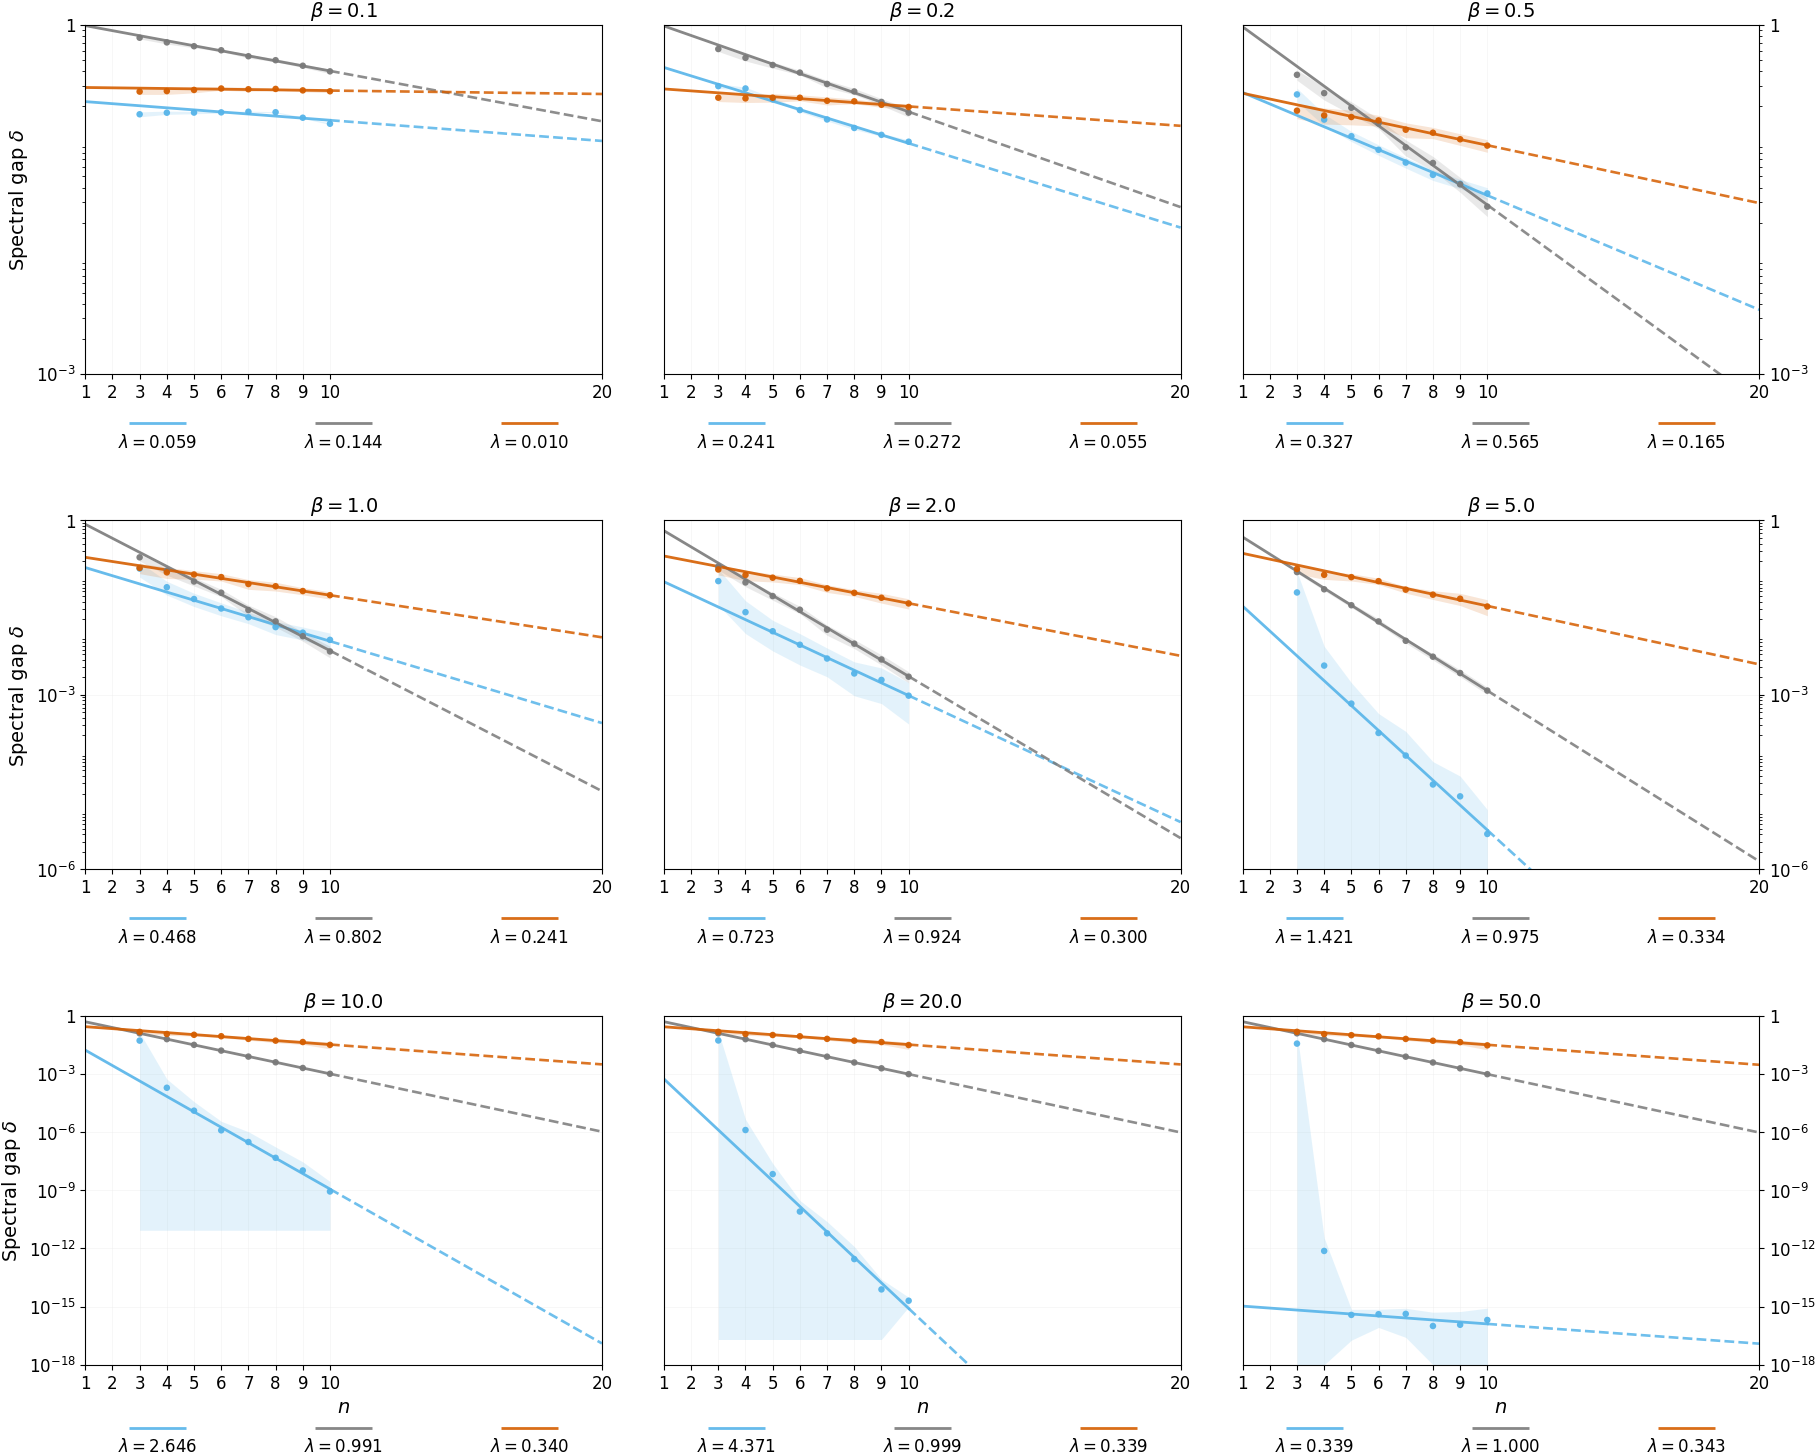

In [118]:
plt.close()
fig, ax = plot_spectral_gap_vs_n_table(fixed_betas=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], ncols=3, n_plot_min=1, n_plot_max=20, statistic="mean+std-tail",
    y_limit_measurement_scale=1.0,
    y_limit_max_extra_orders=5.0,
    y_tick_order_step=3,
    wspace=0.12,
    extrapolation_alpha_factor=0.95,)
plt.savefig("plots/6_spectral_gap_vs_n_stat_mean_std_notail", dpi=300)

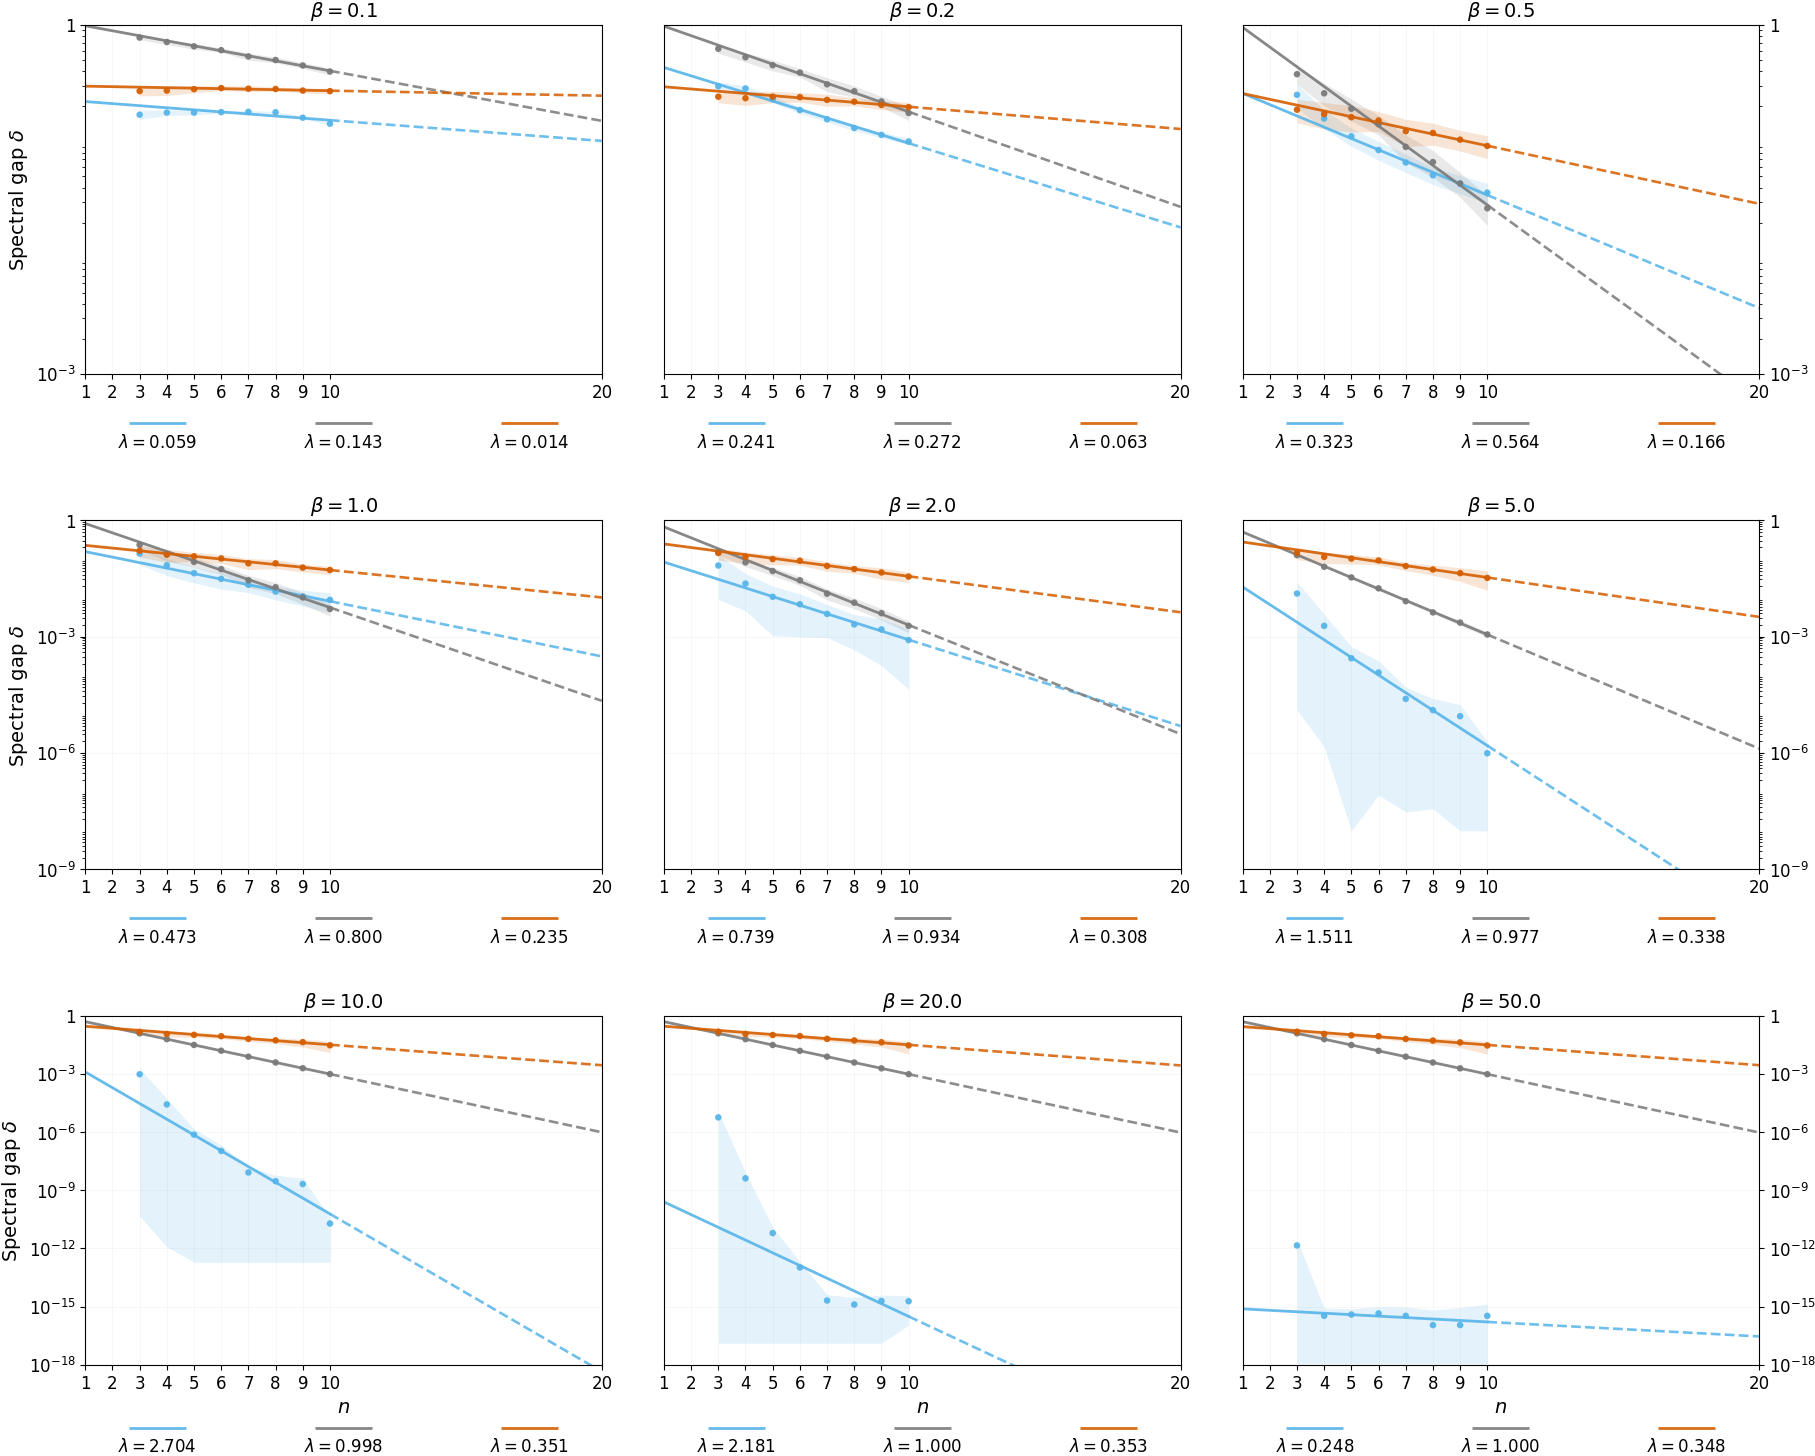

In [119]:
plt.close()
fig, ax = plot_spectral_gap_vs_n_table(fixed_betas=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], ncols=3, n_plot_min=1, n_plot_max=20, statistic="median+mad",
    y_limit_measurement_scale=1.0,
    y_limit_max_extra_orders=5.0,
    y_tick_order_step=3,
    wspace=0.12,
    extrapolation_alpha_factor=0.95,)
plt.savefig("plots/6_spectral_gap_vs_n_stat_median_mad", dpi=300)

## Classical queries plot

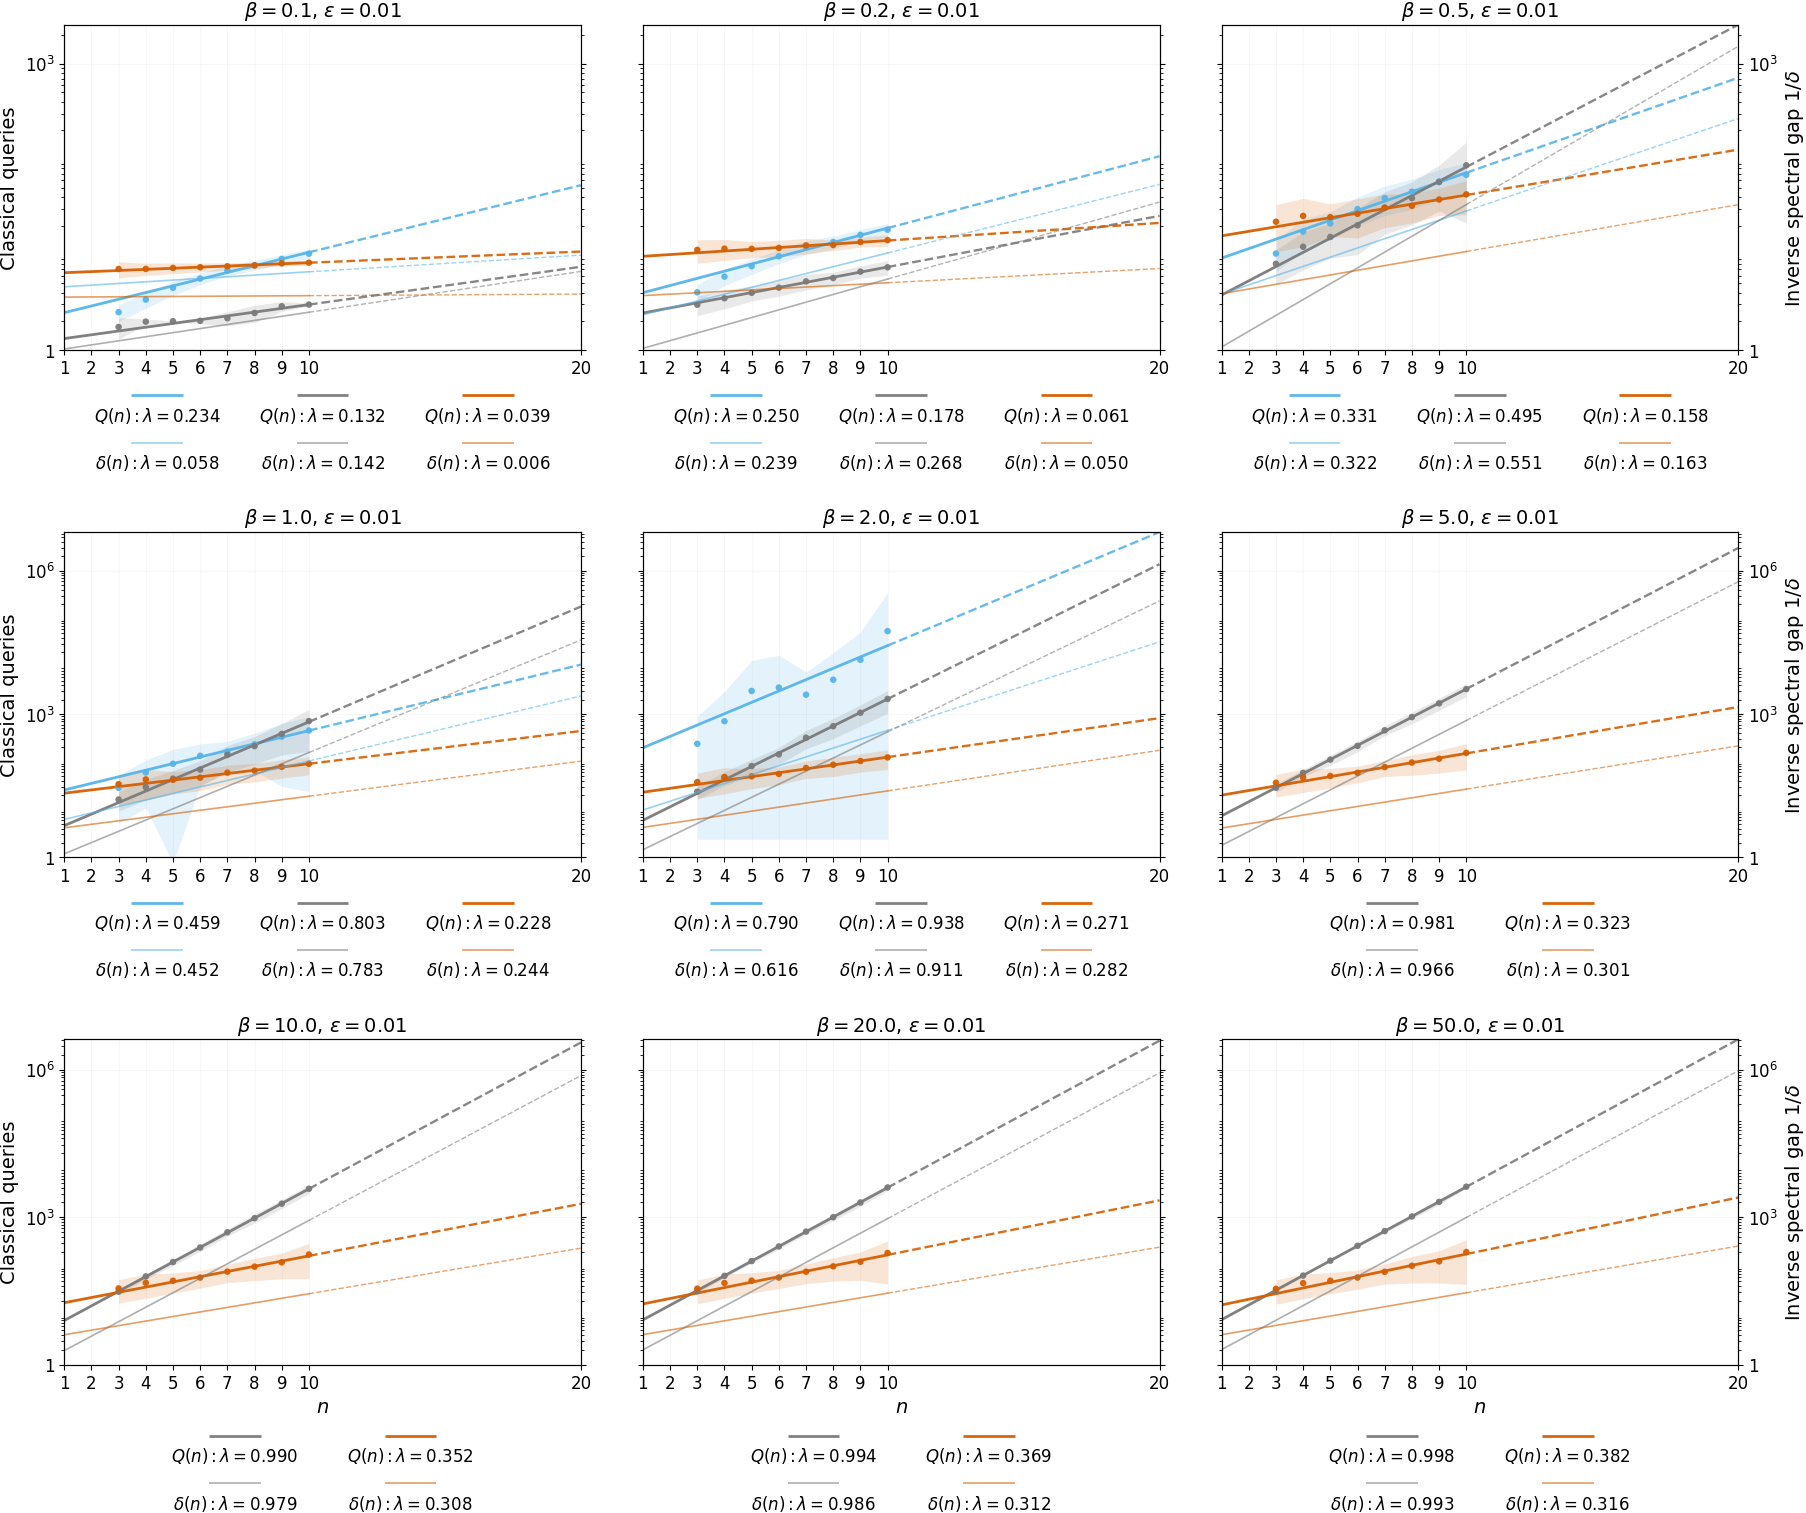

In [120]:
plt.close()
fig, ax, ax_gap = plot_last_step_classical_queries_and_spectral_gap_vs_n_table(
    betas=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], 
    epsilon=1e-2,
    show_inverse_gap=True,
    ncols=3, 
    n_plot_min=1, 
    n_plot_max=20, 
    statistic="mean+std",
    legend_x_span=0.64,
    legend_two_column_x_span=0.34,
    legend_line_half_width=0.050,
    wspace=0.12,
    extrapolation_alpha_factor=0.95,
)
plt.savefig("plots/6_classical_queries_vs_n_stat_mean_std", dpi=300)

## Full annealing plots - queries

In [2]:
# plt.close()
# fig, ax, ax_gap = plot_annealing_classical_and_quantum_queries_vs_n_table(
#     betas=[0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0], 
#     epsilon=1e-2,
#     annealing_schedule_generator=tight_schedule_annealing,
#     ncols=3, 
#     n_plot_min=1, 
#     n_plot_max=80, 
#     statistic="mean+std"
# )
# plt.savefig("plots/6_quantum_queries_vs_n_stat_mean_std", dpi=300)

In [13]:
len(tight_schedule_annealing(10, 4.0))

8

In [14]:
len(tight_schedule_annealing(100, 4.0))

23

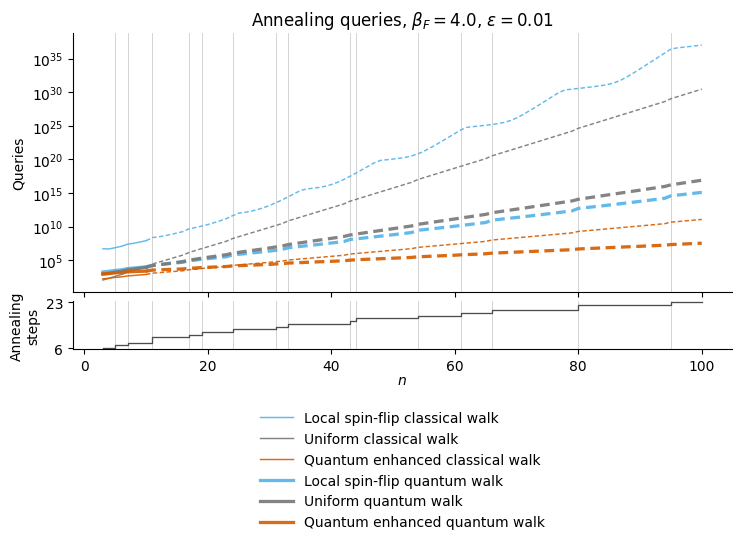

In [35]:
plt.close()
fig, ax = plot_annealing_classical_and_quantum_queries_vs_n(
    beta=4.0,
    epsilon=1e-2,
    annealing_schedule_generator=tight_schedule_annealing,
    statistic="mean+std",
    n_plot_min=3,
    n_plot_max=100,
    n_fit_min=5,
    n_fit_max=10,
    debug=False,
    show_schedule_panel=True,
    show_schedule_vertical_lines=True,
    legend_y_shift=-1.15,
    xlabel_labelpad=0
)

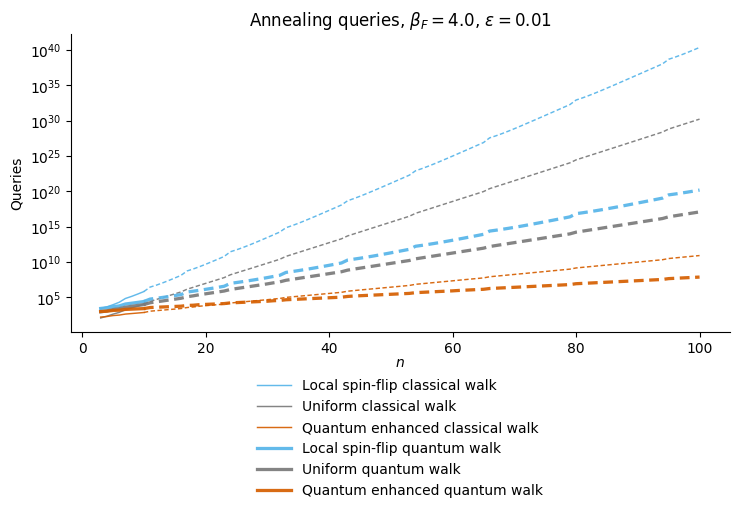

In [44]:
plt.close()
fig, ax = plot_annealing_classical_and_quantum_queries_vs_n(
    beta=4.0,
    epsilon=1e-2,
    annealing_schedule_generator=tight_schedule_annealing,
    statistic="mean+std-tail",
    n_plot_min=3,
    n_plot_max=100,
    n_fit_min=5,
    n_fit_max=10,
    debug=False,
    show_schedule_panel=False,
    show_schedule_vertical_lines=False,
    legend_y_shift=-0.14,
    xlabel_labelpad=0
)

# Runtime

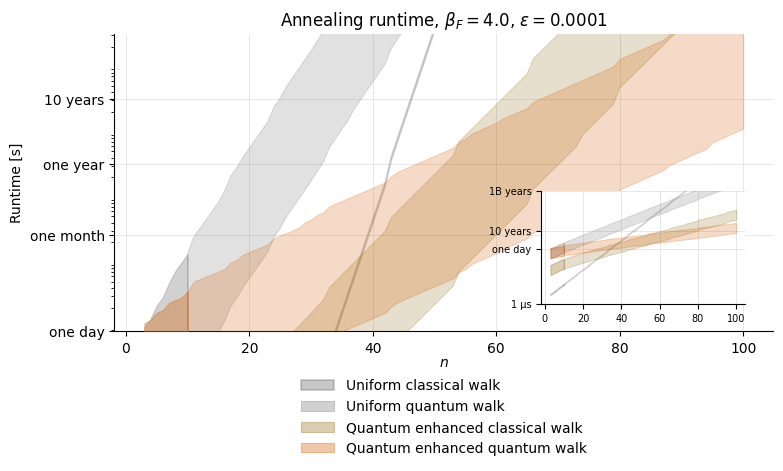

In [56]:
from monaqa2.data.plot_main11 import plot_annealing_classical_and_quantum_queries_vs_n
from monaqa2.data.plot_main11 import plot_annealing_classical_and_quantum_runtime_vs_n, plot_annealing_classical_and_quantum_runtime_fancy_vs_n


plt.close()
fig, ax = plot_annealing_classical_and_quantum_runtime_fancy_vs_n(
    beta=4.0,
    epsilon=1e-4,
    annealing_schedule_generator=tight_schedule_annealing,
    classical_device="fpga",
    mode="compact",
    physical_error_rate_min=1e-4,
    physical_error_rate_max=1e-4,
    physical_operation_time_min=200e-9,
    physical_operation_time_max=20_000e-9,
    physical_measurement_time_min=20e-9,
    physical_measurement_time_max=2_000e-9,
    num_trotter_steps=50,
    statistic="mean+std",
    n_plot_min=3,
    n_plot_max=100,
    n_fit_min=5,
    n_fit_max=10,
    debug=False,
    show_schedule_panel=False,
    show_schedule_vertical_lines=False,
    legend_y_shift=-0.14,
    xlabel_labelpad=0,
)

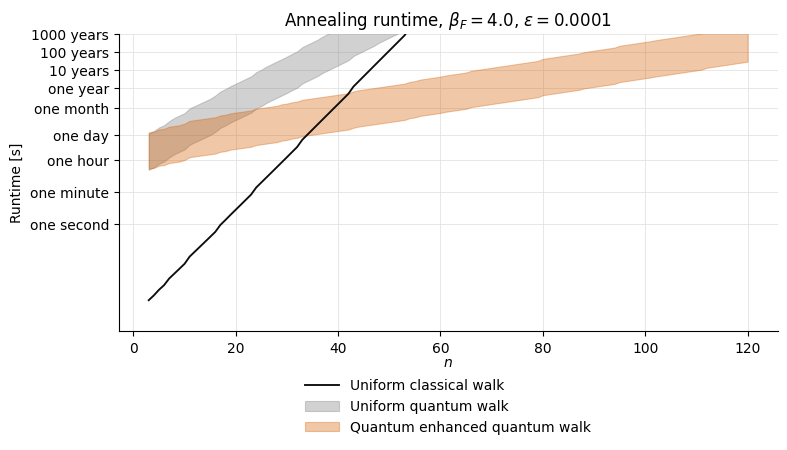

In [63]:
from monaqa2.data.plot_main15 import plot_annealing_classical_and_quantum_queries_vs_n
from monaqa2.data.plot_main15 import plot_annealing_classical_and_quantum_runtime_vs_n, plot_annealing_classical_and_quantum_runtime_fancy_vs_n

plt.close()
fig, ax = plot_annealing_classical_and_quantum_runtime_vs_n(
    beta=4.0,
    epsilon=1e-4,
    annealing_schedule_generator=tight_schedule_annealing,
    classical_device="fpga",
    mode="compact_no_layden",
    physical_error_rate_min=1e-4,
    physical_error_rate_max=1e-4,
    physical_operation_time_min=200e-9,
    physical_operation_time_max=20_000e-9,
    physical_measurement_time_min=20e-9,
    physical_measurement_time_max=2_000e-9,
    num_trotter_steps=50,
    statistic="mean+std",
    n_plot_min=3,
    n_plot_max=120,
    n_fit_min=5,
    n_fit_max=10,
    debug=False,
    show_schedule_panel=False,
    show_schedule_vertical_lines=False,
    legend_y_shift=-0.14,
    xlabel_labelpad=0,
    runtime_ymax_years=1000,
    show_runtime_thresholds=False,
    show_runtime_threshold_labels=False,
    differentiate_projection=False,
)